# Задача определения наилучшей дислокации множества подразделений (MCLP)

В общем виде процесс решения задачи определения наилучшей дислокации множества подразделений можно представить следующим образом:

```{mermaid}
flowchart LR

  model("**МОДЕЛИРОВАНИЕ
          ПАРАМЕТРОВ
          ПРИБЫТИЯ**")
  
  result["**РЕЗУЛЬТАТЫ**"]

  analyze("**АНАЛИЗ**
        ---
        Время прибытия
        ---
        Индекс прикрытия")

  metrics["**МЕТРИКИ**"]

  blp_algs["**ЭВРИСТИЧЕСКИЕ АЛГОРИТМЫ BLP**
        ---
        ADD
        ---
        GNS, GA, SAA, GA+GNS"]

  blp("**ВЫБОР ДИСЛОКАЦИИ**")
        
  model --> result
  metrics --> analyze
  result --> analyze
  analyze --> blp
  blp_algs --> blp
  blp --> model

```

Поиск наилучшей дислокации подразумевает выдвижение гипотез о размещении подразделений и моделирование параметров реагирования прибытия, после чего на основании проведенного анализа делается вывод о том, насколько предложенное размещение подразделений оптимально.

В **Генезис** реализованы следующие алгоритмы решения задачи MCLP:

- Рекомендуемый:
  - `genesis.lscp.LSCP_ADD` Алгоритм жадного добавления (ADD) - *рекомендуемый*,
- Прочие:
  - `genesis.mclp.BestNodesKoptG` Модульный алгоритм Генезис (GNS)
  - `genesis.mclp.BestNodesGA` Генетический алгоритм (GA)
  - `genesis.mclp.BestNodesSA` Алгоритм имитации отжига (SAA)
  - `fire_units.mclp.BestNodesGAKopt` Гибридный алгоритм Генетический алгоритм + Генезис (GA+GNS)

Реализован также ряд дополнительных алгоритмов описываемых в разделе **Для разработчиков**.

## Загрузка исходных данных

In [1]:
import numpy as np
import osmnx as ox
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import genesis as genesis


# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\ngenesis:', genesis.__version__,
      )

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.3 
genesis: 0.1.033


In [2]:
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS


# 1. Загрузка исходных данных
## Загрузка ГДС
G = ox.load_graphml('data/kemerovo/gds.ml')

## Установка скоростного режима
set_graph_travel_times(
    G,
    speeds=DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)

## Упрощение графа (уменьшение количества узлов)
G = ox.simplification.simplify_graph(G)

## Загрузка границ города
borders = gpd.read_file('data/kemerovo/borders.gpkg')

## Загрузка пожарных подразделений
units = gpd.read_file('data/kemerovo/fire_units.gpkg')
### Сопоставление пожарных подразделений с ближайшими узлами ГДС
units['node'] = ox.distance.nearest_nodes(G, units.geometry.x, units.geometry.y)
### Формирование словаря подразделений для передачи алгоритму
units_dict = {k:v for k,v in zip(units['node'], units['name'])}

## Загрузка зданий
buildings = gpd.read_file('data/kemerovo/buildings.gpkg')
### Сопоставление зданий с ближайшими узлами ГДС
centroids = ox.projection.project_gdf(buildings).geometry.centroid
buildings['node'] = ox.distance.nearest_nodes(ox.project_graph(G), 
                                              centroids.x,
                                              centroids.y
                                              )

## Рекомендуемый способ: Алгоритм жадного добавления

Рекомендуемым способом является использование алгоритма жадного добавления **ADD**: `genesis.lscp.LSCP_ADD`.

Данный подход универсален и может быть применен к решению задач **BLP**, **MCLP**, **LSCP**.

Он основан на идее определения точки в при размещении пожарного епо в которой обеспечивается заданное время прибытия к как можно большему количеству объектов защиты. При расчете используется моделирование параметров прибытия подразделений пожарной охраны с использованием матрицы прибытия `genesis.states.ArrivalTimeMatrixState`.

### Матрица прибытия {.unnumbered}

In [3]:
from genesis.states import get_atm

## Расчет матрицы прибытия
matrix = get_atm(G,
                 data             = buildings,
                 data_sample_size = 2000,
                 cutoff           = 10,
                 )

|########################################| 100.0%


### Расчет без учета имеющихся подразделений {.unnumbered}

Определение оптимальной дислокации 4 подразделений с целью минимизации индекса прикрытия (10 минутная зона).

ИП-10: 68.35429545939033


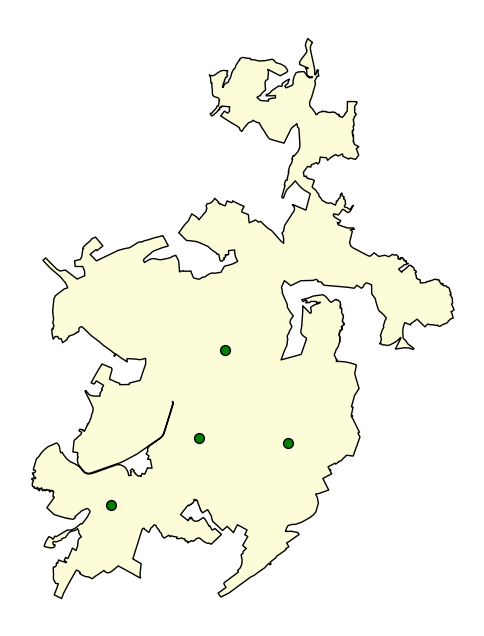

In [4]:
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция остановки
stop_case = lambda dynamic_nodes, **kwargs: len(dynamic_nodes) >= 4      # Расчет проводится для определения оптимальной дислокации 4 подразделений

## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = state,
    matrix              = matrix,
    metric_function     = metric,
    stop_case_function  = stop_case,
)


# 3. Расчет BLP
best_nodes, best_metric = add(
        env          = G,
    )


# 4. Печать результатов
print('ИП-10:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50)
ax.set_axis_off()
plt.show()

### Расчет с учетом имеющихся подразделений {.unnumbered}

Определение оптимальной дислокации 4 подразделений с целью минимизации индекса прикрытия (10 минутная зона). С учетом существующих подразделений.

ИП-10: 92.77339586442123


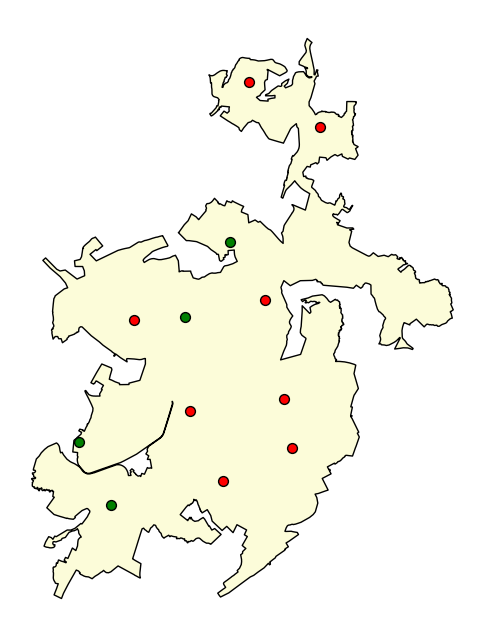

In [5]:
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция остановки
stop_case = lambda dynamic_nodes, **kwargs: len(dynamic_nodes) >= 4      # Расчет проводится для определения оптимальной дислокации 4 подразделений

## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = state,
    matrix              = matrix,
    metric_function     = metric,
    stop_case_function  = stop_case,
)


# 3. Расчет BLP
best_nodes, best_metric = add(
        env          = G,
        static_nodes = units_dict,  # Размещение существующих подразделений пожарной охраны
    )


# 4. Печать результатов
print('ИП-10:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50)
g_nodes.loc[units_dict.keys()].plot(ax=ax, facecolors='r', edgecolors='k', markersize=50)
ax.set_axis_off()
plt.show()

:::{.callout-important}
### Важно 

Алгоритм моделирования `ArrivalTimeMatrixState(matrix)` используется в `LSCP_ADD` только в том случае, если при расчете матрицы прибытия **не было указано** ограничение времени прибытия `cutoff`.

Если же в функции `get_atm` **было указано** ограничение времени прибытия `cutoff` (так как в примере выше), то следует использовать алгоритм моделирования `FirstArrivalUnitState()`

:::

## Дополнительные способы

### Модульный алгоритм Генезис (GNS) {.unnumbered}

Определение размещения 3 подразделений с учетом существующих.

ИП-10: 76.27371562566617


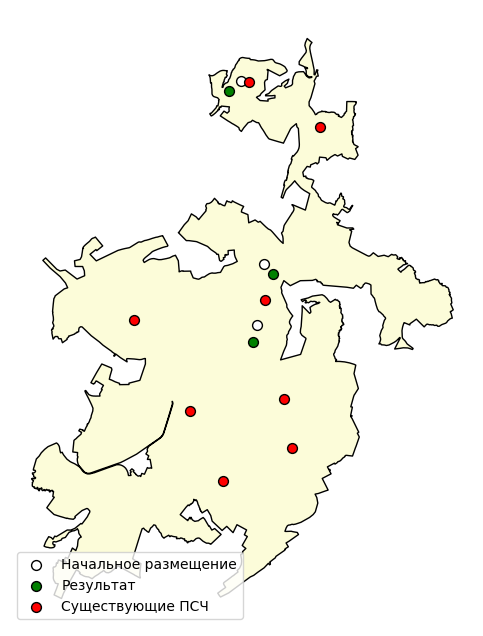

In [6]:
from genesis.mclp import BestNodesKoptG
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding
from fire_units.best_points import BestNodeHillClimbing_HD_Max_Mean     # Версия алгоритма подъема по холмам с локальной оптимизацией

# 1. Исходные данные
## Определение стартового размещения (произвольным образом) для 3 подразделений
g_nodes_list = list(G.nodes())
start_dict = {
    g_nodes_list[1000]: 'псч-1',
    g_nodes_list[2000]: 'псч-2',
    g_nodes_list[3000]: 'псч-3',
}


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция определения лучшего узла
best_point = BestNodeHillClimbing_HD_Max_Mean(
    state_function      = state,
    metric_function     = metric,
)

## Сборка и инициализация алгоритма GNS
gns = BestNodesKoptG(  
    state_function      = state,
    metric_function     = metric,
    best_point_function = best_point,
)


# 3. Расчет GNS
best_nodes, best_metric = gns(
        env             = G,
        dynamic_nodes   = start_dict,  # Начальная позиция ПСЧ
        static_nodes    = units_dict,  # Размещение существующих подразделений пожарной охраны
    )


# 4. Печать результатов
print('ИП-10:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[start_dict.keys()].plot(ax=ax, facecolors='w', edgecolors='k', markersize=50, label='Начальное размещение')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50, label='Результат')
g_nodes.loc[units_dict.keys()].plot(ax=ax, facecolors='r', edgecolors='k', markersize=50, label='Существующие ПСЧ')
ax.set_axis_off()
plt.legend()
plt.show()

### Генетический алгоритм (GA) {.unnumbered}

Определение размещения 5 ПСЧ без учета существующих с целью минимизации среднего времени прибытия к зданиям.

Эпоха: 0, Метрика: 11.229331244762554
Эпоха: 1, Метрика: 11.229331244762554
Эпоха: 2, Метрика: 10.90593158042567
Эпоха: 3, Метрика: 10.90593158042567
Эпоха: 4, Метрика: 10.522319063470668
Эпоха: 5, Метрика: 10.522319063470668
Эпоха: 6, Метрика: 10.522319063470668
Эпоха: 7, Метрика: 10.522319063470668
Эпоха: 8, Метрика: 10.522319063470668
Эпоха: 9, Метрика: 9.941536568333985
Среднее время прибытия: 9.941536568333985


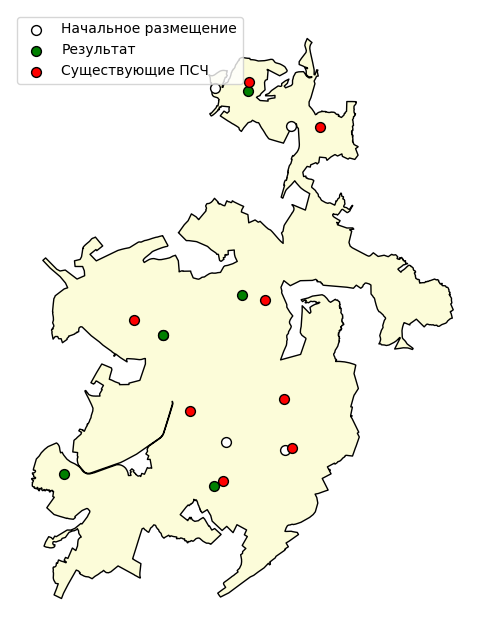

In [7]:
from genesis.mclp import BestNodesGA
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import ArrivalTimeBuilding
from genesis.point_selectors import RandomNodesSelector     # Функция выбора случайного узла

# 1. Исходные данные
## Определение стартового размещения (произвольным образом) для 3 подразделений
g_nodes_list = list(G.nodes())
start_dict = {
    g_nodes_list[1500]: 'псч-1',
    g_nodes_list[2500]: 'псч-2',
    g_nodes_list[3500]: 'псч-3',
    g_nodes_list[4500]: 'псч-4',
    g_nodes_list[5500]: 'псч-5',
}


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = ArrivalTimeBuilding(buildings) # Используется метрика среднего времени прибытия к зданиям

## Функция выбора узла (для ГА - случайный выбор)
selector = RandomNodesSelector()

## Функция печати хода расчета по итогам эпохи
epoch_end = lambda epoch, best_metric, **kwargs: print(f'Эпоха: {epoch}, Метрика: {best_metric}')

## Сборка и инициализация алгоритма GNS
ga = BestNodesGA(  
    state_function      = state,
    metric_function     = metric,
    node_selector       = selector,
    population_size     = 30,               # Размер популяции
    epochs              = 10,               # Количество эпох
    elite_size          = 15,               # Размер элитной группы
    mutation_rate       = 0.05,             # Вероятность мутации
    mutation_max_count  = 3,                # Максимальное количество мутаций
    epoch_end_function  = epoch_end,        # Вывод хода расчета по итогам эпохи
)


# 3. Расчет GA
best_nodes, best_metric = ga(
        env             = G,
        dynamic_nodes   = start_dict,  # Начальная позиция ПСЧ
    )


# 4. Печать результатов
print('Среднее время прибытия:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[start_dict.keys()].plot(ax=ax, facecolors='w', edgecolors='k', markersize=50, label='Начальное размещение')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50, label='Результат')
g_nodes.loc[units_dict.keys()].plot(ax=ax, facecolors='r', edgecolors='k', markersize=50, label='Существующие ПСЧ')
ax.set_axis_off()
plt.legend()
plt.show()

### Алгоритм имитации отжига (SAA) {.unnumbered}

Определение размещения 5 ПСЧ без учета существующих с целью максимизации ИП-8 (*для примера*).

In [ ]:
from genesis.mclp import BestNodesSA
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding
from genesis.point_selectors import RandomNodesSelector     # Функция выбора случайного узла

# 1. Исходные данные
## Определение стартового размещения (произвольным образом) для 3 подразделений
g_nodes_list = list(G.nodes())
start_dict = {
    g_nodes_list[1500]: 'псч-1',
    g_nodes_list[2500]: 'псч-2',
    g_nodes_list[3500]: 'псч-3',
    g_nodes_list[4500]: 'псч-4',
    g_nodes_list[5500]: 'псч-5',
}


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=8) # Используется метрика среднего времени прибытия к зданиям

## Функция выбора узла (для ГА - случайный выбор)
selector = RandomNodesSelector()

## Функция печати хода расчета по итогам эпохи
turn_end = lambda turn, best_metric, **kwargs: print(f'Шаг: {turn}, Метрика: {best_metric}  ', end='\r')

## Сборка и инициализация алгоритма GNS
saa = BestNodesSA(  
    state_function      = state,
    metric_function     = metric,
    node_selector       = selector,
    turn_end_function   = turn_end,        # Вывод хода расчета по итогам шага расчета
)


# 3. Расчет GA
best_nodes, best_metric = saa(
        env             = G,
        dynamic_nodes   = start_dict,  # Начальная позиция ПСЧ
    )


# 4. Печать результатов
print('ИП-8:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[start_dict.keys()].plot(ax=ax, facecolors='w', edgecolors='k', markersize=50, label='Начальное размещение')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50, label='Результат')
g_nodes.loc[units_dict.keys()].plot(ax=ax, facecolors='r', edgecolors='k', markersize=50, label='Существующие ПСЧ')
ax.set_axis_off()
plt.legend()
plt.show()

### Гибридный алгоритм Генетический алгоритм + Генезис (GA+GNS) {.unnumbered}

Определение размещения 5 ПСЧ без учета существующих с целью минимизации максимального времени прибытия.

Эпоха: 0, Метрика: 11.071304275342618
Эпоха: 1, Метрика: 11.071304275342618
Эпоха: 2, Метрика: 11.071304275342618
Эпоха: 3, Метрика: 11.071304275342618
Эпоха: 4, Метрика: 11.071304275342618
Эпоха: 5, Метрика: 11.071304275342618
Эпоха: 6, Метрика: 11.071304275342618
Эпоха: 7, Метрика: 11.071304275342618
Эпоха: 8, Метрика: 11.071304275342618
Эпоха: 9, Метрика: 11.071304275342618
Максимальное время прибытия: 10.294091201260544


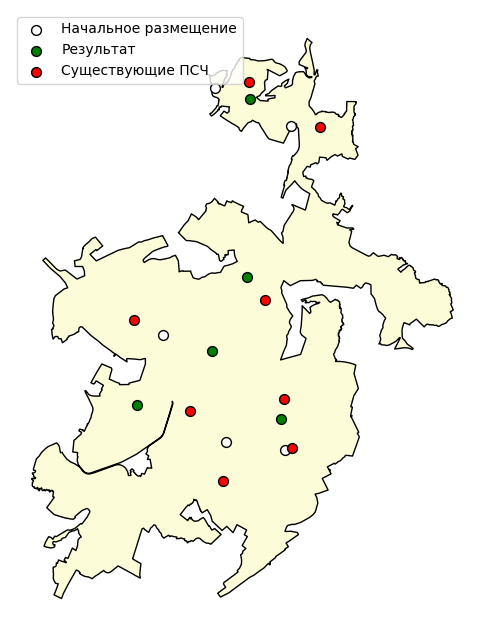

In [15]:
from genesis.mclp import BestNodesKoptG
from fire_units.mclp import BestNodesGAKopt
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import ArrivalTimeBuilding
from genesis.point_selectors import RandomNodesSelector     # Функция выбора случайного узла
from fire_units.best_points import BestNodeHillClimbing_HD_Max_Mean

# 1. Исходные данные
## Определение стартового размещения (произвольным образом) для 3 подразделений
g_nodes_list = list(G.nodes())
start_dict = {
    g_nodes_list[1500]: 'псч-1',
    g_nodes_list[2500]: 'псч-2',
    g_nodes_list[3500]: 'псч-3',
    g_nodes_list[4500]: 'псч-4',
    g_nodes_list[5500]: 'псч-5',
}


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = ArrivalTimeBuilding(buildings)  #, f=np.max) # Используется метрика максимального времени прибытия к зданиям

## Функция выбора узла (для ГА - случайный выбор)
selector = RandomNodesSelector()

## Функция печати хода расчета по итогам эпохи
epoch_end = lambda epoch, best_metric, **kwargs: print(f'Эпоха: {epoch}, Метрика: {best_metric}')

## Алгоритм Генезис
## Функция определения лучшего узла
best_point = BestNodeHillClimbing_HD_Max_Mean(
    state_function      = state,
    metric_function     = metric,
)

## Сборка и инициализация алгоритма GNS
gns = BestNodesKoptG(  
    state_function      = state,
    metric_function     = metric,
    best_point_function = best_point,
    iterations          = 3,
)

## Сборка и инициализация алгоритма GNS
gagns = BestNodesGAKopt(  
    state_function      = state,
    metric_function     = metric,
    kopt_function       = gns,              # Функция Генезис
    node_selector       = selector,
    population_size     = 30,               # Размер популяции
    epochs              = 10,               # Количество эпох
    elite_size          = 15,               # Размер элитной группы
    mutation_rate       = 0.5,              # Вероятность мутации
    mutation_max_count  = 3,                # Максимальное количество мутаций
    epoch_end_function  = epoch_end,        # Вывод хода расчета по итогам эпохи
)


# 3. Расчет GA
best_nodes, best_metric = gagns(
        env             = G,
        dynamic_nodes   = start_dict,  # Начальная позиция ПСЧ
    )


# 4. Печать результатов
print('Максимальное время прибытия:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
fig, ax = plt.subplots(figsize=(8,8))
borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
g_nodes.loc[start_dict.keys()].plot(ax=ax, facecolors='w', edgecolors='k', markersize=50, label='Начальное размещение')
g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50, label='Результат')
g_nodes.loc[units_dict.keys()].plot(ax=ax, facecolors='r', edgecolors='k', markersize=50, label='Существующие ПСЧ')
ax.set_axis_off()
plt.legend()
plt.show()

In [19]:
import random

import networkx as nx

from genesis.states import FirstArrivalUnitState
from fire_units.metrics import ArrivalTimeBuilding
from genesis.point_selectors import RandomNodesSelector
from genesis.core import MCLPBase, MetricBase, PointSelectorBase, StateBase     # Функция выбора случайного узла
from genesis.tools import list_dict_concat


class BestNodesGA2(MCLPBase):
    '''
    Поиск лучших узлов для размещения n объектов.

    Расчет производится генетическим алгоритмом.

    ## Область применения
    Определение размещения множества узлов в графе, при котором 
    обеспечиваются наилучшие некоторые целевые метрики. 
    
    Дает решение высокой точности. Хорошо подходит для больших графов.
    '''

    def __init__(self,
                 state_function     :StateBase,
                 metric_function    :MetricBase,
                 node_selector      :PointSelectorBase,
                 population_size    :int = 25,
                 epochs             :int = 50,
                 mutation_rate      :float = 0.5,
                 elite_size         :int = 0,
                 appr_val_in_area   :float = 0,
                 mutation_max_count :int | float = 1,
                 bad_val_in_area    :int = 1000,
                 epoch_end_function :callable = None,
                 stop_case_function :callable = None,
                 **kwargs) -> None:
        '''
        ## Аргументы
        `state_function`: StateBase
            функция расчета состояния окружения
        `metric_function`: MetricBase
            Функция расчета метрики
        `node_selector`: PointSelectorBase
            Функция выбора узла.
        `population_size`:int = 25
            Размер популяции
        `epochs`: int = 50
            Количество эпох расчета
        `mutation_rate`: float = 0.1
            Вероятность единичной мутации
        `elite_size`: int =  0
            Количество особей в элитной группе.
            Если указан 0, то механизм элитизма не задействуется.
        `appr_val_in_area`: int=0
            Доля узлов графа в пределах area, покрытие которой считается приемлемой для принятия расчетной метрики. 
            Если при расчете метрик, из стартового узла (узлов) достижимо меньшее количество узлов,
            то такой узел не рассматривается.
            При расчет размещения нескольких узлов неминуемо возникает ситуация при которой
            часть территории area будет недостижима. Поэтому по умолчанию считается
        `mutation_max_count`: int = 1
            Максимальное количество единиц мутации.
            Если указано десятичное число от 0 до 1, то используется доля 
            от общего количества хромосом (подразделений)
        `bad_val_in_area`: int=1000
            Значение указываемое для узла, в случае если
            из него нельзя попасть в `appr_val_in_area` долю узлов в пределах
            `area`.
        `epoch_end_function`: callable = None
            Функция вызываемая после каждой эпохи расчета.
        `stop_case_function`: callable = None
            Функция проверки достигнута ли цель расчета
        '''
        if population_size <= 5:
            raise ValueError('Размер популяции должен быть > 0, так же не рекомендуется использовать размер популяции < 5')
        if epochs  <=  0:
            raise ValueError('Количество эпох должно быть > 0')
        if mutation_max_count  <=  0:
            raise ValueError('Максимальное количество единиц мутации должно быть > 0')
        if mutation_rate <0 or mutation_rate > 1:
            raise ValueError('Вероятность мутации должна лежать в диапазоне (0,1)')
        if appr_val_in_area <0 or appr_val_in_area > 1:
            raise ValueError('Доля узлов графа в пределах area, должна лежать в диапазоне (0,1)')
        if elite_size < 0:
            raise ValueError('Количество особей в элитной группе должно быть >= 0')
        
        self.population_size = population_size
        self.epochs = epochs
        self.mutation_rate = mutation_rate
        self.elite_size = elite_size
        self.appr_val_in_area = appr_val_in_area
        self.mutation_max_count = mutation_max_count
        self.bad_val_in_area = bad_val_in_area
        self.epoch_end_function = epoch_end_function
        self.stop_case_function = stop_case_function
        self.node_selector = node_selector
        super().__init__(state_function, metric_function, **kwargs)

    def _fit_function(self, env, nodes, area=None, **kwargs):
        '''
        Расчет функции приспособленности
        '''
        # 2.1. Расчет состояния
        times, _ = self.state_function(env=env, points=nodes, area=area, **kwargs)

        if not area is None:
            appr_nodes_count = area.sum() * self.appr_val_in_area
            if len(times) < appr_nodes_count:
                print('Расстановка не обеспечивает требуемую степень прикрытия территории area')
                return self.bad_val_in_area

        # 2.2. Расчет стартовой метрики состояния и определение стартового размещения
        best_metric = self.metric_function(times, **kwargs)

        return best_metric

    def _mutate(self, env, new_dynamic_nodes, area):
        '''
        Мутация особи
        '''
        if self.mutation_max_count >= 1:
            mutation_count = self.mutation_max_count
        elif self.mutation_max_count > 0 and self.mutation_max_count < 1:
            mutation_count = int(len(new_dynamic_nodes) * self.mutation_max_count)
        else:
            mutation_count = len(new_dynamic_nodes)
        if mutation_count == 0:
            mutation_count = 1
        for _ in range(mutation_count):
            if random.random() < self.mutation_rate:
                # Выбор случайного элемента в словаре и удаление его из new_dynamic_nodes
                node, unit = random.choice(list(new_dynamic_nodes.items()))
                del new_dynamic_nodes[node]

                # Поиск нового узла, которого при этом нет в new_dynamic_nodes
                node = self.node_selector(env=env, points=new_dynamic_nodes, area=area)
                new_dynamic_nodes[node] = unit

        return  new_dynamic_nodes

    def __call__(self,
                 env:nx.Graph,
                 dynamic_nodes: dict,
                 static_nodes: dict = None,
                 area: pd.Series = None,
                 **kwargs):
        '''
        Запуск работы генетического алгоритма

        ## Аргументы
        `env`:nx.Graph
            Граф улично-дорожной сети
        `dynamic_nodes`: list|dict
            Список стартовых узлов графа в которых размещены
            подразделения оптимальные места которых следует определить.
        `static_nodes`: list|dict = None
            Список стартовых узлов графа в которых размещены
            подразделения изменять размещение которых не следует.
        `area`: pd.Series = None
            Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
            Если не указана, расчет производится для всех узлов графа.
        '''

        # 0. Проверка корректности пришедших данных
        if not isinstance(env, nx.Graph):
            raise TypeError("Тип аргумента `env` должен быть `Graph`!")
        if not isinstance(dynamic_nodes, dict):
            raise TypeError("Тип аргумента `dynamic_nodes` должен быть `dict`!")
        if not static_nodes is None and not isinstance(static_nodes, dict):
            raise TypeError("Тип аргумента `static_nodes` должен быть `dict`!")
        if len(dynamic_nodes) < 2:
            raise ValueError(f'Количество элементов `dynamic_nodes` не может быть меньше 2. Сейчас {len(dynamic_nodes)}')
        if not area is None and not isinstance(area, pd.Series):
            raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')


        # 1.1. Если статические узлы не указаны - заменяем значение переменной с None
        # на {}
        if static_nodes is None:
            static_nodes = {}

        # Последовательность узлов графа (для последующего обращения к нему)
        # g_nodes = list(env.nodes())

        # ===================================== Генетический алгоритм ==============
        # 1. Создание стартовой популяции
        # population = [dynamic_nodes for _ in range(self.population_size)]
        # # Обязательно сохраняется один экземпляр исходного бота!
        population = [self._mutate(env, dynamic_nodes.copy(), area) for _ in range(self.population_size - 1)] + [dynamic_nodes]

        # Оценка приспособленности всех особей
        bot_fit = [self._fit_function(env=env,
                                      nodes=list_dict_concat(dn, static_nodes),
                                      area=area,
                                      **kwargs) for dn in population]
        # print(-2, bot_fit)
        if self.metric_function.compare(1,2) == 1:        # Для минимизации:
            max_val  = max(bot_fit)
            # weights = [1.1*max_val-x for x in bot_fit]
            weights = [max_val-x for x in bot_fit]
            # weights = [x/max_val for x in bot_fit]
            best_metric = min(bot_fit)
        else:                                           # Для максимизации:
            weights = bot_fit
            best_metric = max(bot_fit)
        best_bot = population[bot_fit.index(best_metric)]
        # print(-1, best_metric, weights)

        # 2. На каждой эпохе
        for epoch in range(self.epochs):

            # 2.0 Элитарность
            if self.elite_size>0:
                # Определение весов
                pop_weight = pd.DataFrame({'w': weights, 'p': population})
                # print(1, weights)
                if self.metric_function.compare(1,2) == 1:                      # Для минимизации:
                    pop_weight = pop_weight.sort_values('w', ascending=True)
                else:                                                           # Для максимизации
                    pop_weight = pop_weight.sort_values('w', ascending=False)
                pop_weight = pop_weight.iloc[:self.elite_size]
                population = pop_weight['p'].to_list()
                weights = pop_weight['w'].to_list()
                # print(2, weights)
                
                new_population = population.copy()
            else:
                new_population = []

            # 2.1 Генерация новой популяции
            for _ in range(self.population_size - self.elite_size):

                # Отбор по правилу рулетки
                parent_bot_1 = random.choices(population, weights=weights)[0]
                parent_bot_2 = random.choices(population, weights=weights)[0]

                # Скрещивание (одноточечное)
                split_point = int(len(parent_bot_1)/2)
                left_gen_vals = list(parent_bot_1.values())[:split_point]
                right_gen_vals  = list(parent_bot_1.values())[split_point:]
                left_genome_part = {k:v for k, v in parent_bot_1.items() if v in left_gen_vals}
                right_genome_part = {k:v for k, v in parent_bot_2.items() if v in right_gen_vals}
                new_dynamic_nodes = {**left_genome_part, **right_genome_part}

                # Мутация (выбор произвольного узла)
                new_dynamic_nodes = self._mutate(env=env,
                                                 new_dynamic_nodes=new_dynamic_nodes,
                                                 area=area)

                # Добавляем его в новую популяцию
                new_population.append(new_dynamic_nodes)

            # 2.2 Заменяем предыдущую популяцию новой
            population = new_population

            # 2.3 Оценка приспособленности всех особей
            bot_fit = [self._fit_function(env = env,
                                      nodes   = list_dict_concat(dn, static_nodes),
                                      area    = area,
                                      **kwargs) for dn in population]

            # 2.4 Определение лучшего на эпохе значения метрики
            # и весов в зависимости от приспособленности        
            if self.metric_function.compare(1,2)==1:    # Для минимизации:
                max_val  = max(bot_fit)
                weights = [max_val-x for x in bot_fit]
                cur_metric = min(bot_fit)
            else:                                       # Для максимизации
                weights = bot_fit
                cur_metric = max(bot_fit)
            
            # 2.5 Нормализация весов (для более выраженной точности расчета)
            # print(1, weights)
            # weights = bot_fit
            # weights = (weights - np.min(weights)) / (np.max(weights) - np.min(weights))
            # print(2, weights)

            # 2.6 Определяем лучше ли лучшее на эпохе решение чем имеющееся
            if self.metric_function.compare(best_metric, cur_metric) == cur_metric:
                best_bot = population[bot_fit.index(cur_metric)]
                best_metric  = cur_metric

            # 2.7 Выполнение функции окончания расчета на эпохе
            if self.epoch_end_function:
                self.epoch_end_function(epoch=epoch,
                                        best_metric=best_metric,
                                        cur_metric=cur_metric,
                                        best_bot=best_bot)

            # 2.8 Если достигнута цель расчета, выходим из цикла
            if self.stop_case_function:
                if self.stop_case_function(value=best_metric,
                            iteration=epoch,
                            best_metric=best_metric,
                            dynamic_nodes=best_bot,
                            static_nodes=static_nodes):
                    break

        return best_bot, best_metric













# 1. Исходные данные
## Определение стартового размещения (произвольным образом) для 3 подразделений
g_nodes_list = list(G.nodes())
start_dict = {
    g_nodes_list[1500]: 'псч-1',
    g_nodes_list[2500]: 'псч-2',
    g_nodes_list[3500]: 'псч-3',
    g_nodes_list[4500]: 'псч-4',
    g_nodes_list[5500]: 'псч-5',
}


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = ArrivalTimeBuilding(buildings, f=np.mean) # Используется метрика среднего времени прибытия к зданиям

## Функция выбора узла (для ГА - случайный выбор)
selector = RandomNodesSelector()

## Функция печати хода расчета по итогам эпохи
epoch_end = lambda epoch, best_metric, **kwargs: print(f'Эпоха: {epoch}, Метрика: {best_metric}')

## Сборка и инициализация алгоритма GNS
ga = BestNodesGA2(  
    state_function      = state,
    metric_function     = metric,
    node_selector       = selector,
    population_size     = 30,               # Размер популяции
    epochs              = 10,               # Количество эпох
    elite_size          = 10,               # Размер элитной группы
    mutation_rate       = 0.5,              # Вероятность мутации
    mutation_max_count  = 3,                # Максимальное количество мутаций
    epoch_end_function  = epoch_end,        # Вывод хода расчета по итогам эпохи
)


# 3. Расчет GA
best_nodes, best_metric = ga(
        env             = G,
        dynamic_nodes   = start_dict,  # Начальная позиция ПСЧ
    )


# 4. Печать результатов
print('Среднее время прибытия:', best_metric)

## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
# fig, ax = plt.subplots(figsize=(8,8))
# borders.plot(ax=ax, color='#fcfcd9', edgecolor='black')
# g_nodes.loc[start_dict.keys()].plot(ax=ax, facecolors='w', edgecolors='k', markersize=50, label='Начальное размещение')
# g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='g', edgecolors='k', markersize=50, label='Результат')
# g_nodes.loc[units_dict.keys()].plot(ax=ax, facecolors='r', edgecolors='k', markersize=50, label='Существующие ПСЧ')
# ax.set_axis_off()
# plt.legend()
# plt.show()

Эпоха: 0, Метрика: 10.886124098044773
Эпоха: 1, Метрика: 10.886124098044773
Эпоха: 2, Метрика: 10.886124098044773
Эпоха: 3, Метрика: 10.886124098044773
Эпоха: 4, Метрика: 10.886124098044773
Эпоха: 5, Метрика: 10.886124098044773
Эпоха: 6, Метрика: 10.886124098044773
Эпоха: 7, Метрика: 10.886124098044773
Эпоха: 8, Метрика: 10.886124098044773
Эпоха: 9, Метрика: 10.886124098044773
Среднее время прибытия: 10.886124098044773


In [12]:
w = [1,2,1,3,4,5,3,2,4,8]
p = [1,2,3,4,1,2,3,4,5,3]

df = pd.DataFrame({'w': w, 'p': p})
df

,w,p
0,1,1
1,2,2
2,1,3
3,3,4
4,4,1
5,5,2
6,3,3
7,2,4
8,4,5
9,8,3


In [13]:
df.sort_values('w', ascending=False)

,w,p
9,8,3
5,5,2
4,4,1
8,4,5
3,3,4
6,3,3
1,2,2
7,2,4
0,1,1
2,1,3
